In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate linearly separable binary classification data
def generate_data(n_samples=100):
    # Class 0: centered at (2, 2)
    class0 = torch.randn(n_samples // 2, 2) * 0.5 + torch.tensor([2.0, 2.0])
    labels0 = torch.zeros(n_samples // 2, dtype=torch.long)
    
    # Class 1: centered at (4, 4)
    class1 = torch.randn(n_samples // 2, 2) * 0.5 + torch.tensor([4.0, 4.0])
    labels1 = torch.ones(n_samples // 2, dtype=torch.long)
    
    # Combine data
    X = torch.cat([class0, class1], dim=0)
    y = torch.cat([labels0, labels1], dim=0)
    
    # Shuffle
    indices = torch.randperm(n_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

# Generate data
X, y = generate_data(n_samples=100)
print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Class 0: {(y == 0).sum().item()}, Class 1: {(y == 1).sum().item()}")
print(f"\nFirst 5 samples:")
for i in range(5):
    print(f"  X[{i}] = {X[i].tolist()}, y[{i}] = {y[i].item()}")

Data shape: torch.Size([100, 2])
Labels shape: torch.Size([100])
Class distribution: Class 0: 50, Class 1: 50

First 5 samples:
  X[0] = [1.6155805587768555, 2.381222724914551], y[0] = 0
  X[1] = [4.515545845031738, 3.6476175785064697], y[1] = 1
  X[2] = [2.3052332401275635, 2.6673688888549805], y[2] = 0
  X[3] = [4.180917263031006, 4.999673366546631], y[3] = 1
  X[4] = [3.2832393646240234, 3.7167365550994873], y[4] = 1


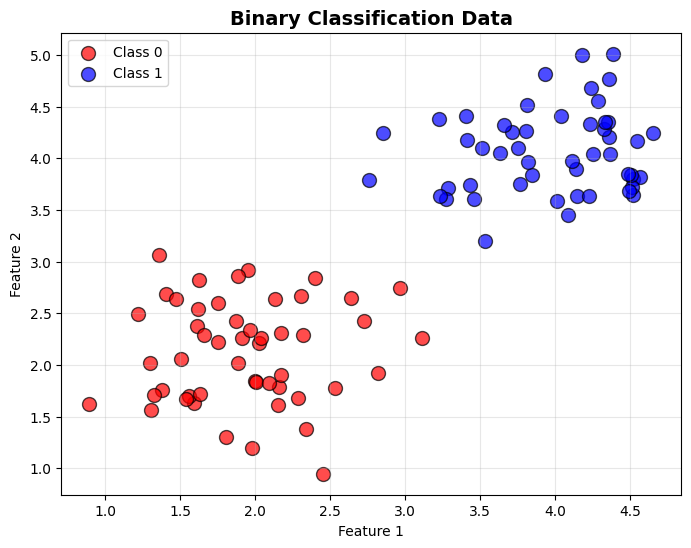

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', s=100, alpha=0.7, edgecolors='black')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', s=100, alpha=0.7, edgecolors='black')
plt.title('Binary Classification Data', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=100):
        """
        Perceptron binary classifier implementation from scratch
        
        Parameters:
        -----------
        learning_rate : float
            Learning rate for weight updates
        n_epochs : int
            Number of training epochs
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.training_errors = []  # Track errors per epoch
        
    def activation(self, z):
        """
        Step activation function
        Returns 1 if z >= 0, else 0
        """
        return torch.where(z >= 0, torch.ones_like(z), torch.zeros_like(z))
    
    def predict_single(self, x):
        """
        Predict class for a single sample
        
        Formula: y_hat = activation(w^T * x + b)
        """
        z = torch.dot(self.weights, x) + self.bias
        return self.activation(z).long()
    
    def fit(self, X, y):
        """
        Train the Perceptron
        
        Parameters:
        -----------
        X : torch.Tensor
            Training data of shape (n_samples, n_features)
        y : torch.Tensor
            Labels of shape (n_samples,) with values in {0, 1}
        """
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zeros
        self.weights = torch.zeros(n_features)
        self.bias = torch.tensor(0.0)
        
        print(f"Training Perceptron")
        print(f"Learning rate: {self.learning_rate}")
        print(f"Epochs: {self.n_epochs}")
        print(f"Initial weights: {self.weights.tolist()}")
        print(f"Initial bias: {self.bias.item()}\n")
        
        # Training loop
        for epoch in range(self.n_epochs):
            errors = 0
            
            # Iterate through each training example
            for i in range(n_samples):
                x_i = X[i]
                y_i = y[i]
                
                # Make prediction
                y_pred = self.predict_single(x_i)
                
                # Compute error
                error = y_i - y_pred
                
                # Update weights and bias if error exists
                if error != 0:
                    errors += 1
                    # Weight update: w = w + learning_rate * error * x
                    self.weights += self.learning_rate * error * x_i
                    # Bias update: b = b + learning_rate * error
                    self.bias += self.learning_rate * error
            
            # Store errors for this epoch
            self.training_errors.append(errors)
            
            # Print progress
            if epoch % 10 == 0 or epoch == self.n_epochs - 1:
                accuracy = 100 * (1 - errors / n_samples)
                print(f"Epoch {epoch:3d}: Errors = {errors:3d}, Accuracy = {accuracy:.2f}%")
            
            # Early stopping if no errors
            if errors == 0:
                print(f"\nConverged at epoch {epoch}! No classification errors.")
                break
        
        print(f"\nFinal weights: {self.weights.tolist()}")
        print(f"Final bias: {self.bias.item():.4f}")
        
        return self
    
    def predict(self, X):
        """
        Predict classes for multiple samples
        
        Parameters:
        -----------
        X : torch.Tensor
            Data of shape (n_samples, n_features)
        
        Returns:
        --------
        predictions : torch.Tensor
            Predicted labels of shape (n_samples,)
        """
        # Compute z = X @ w + b
        z = X @ self.weights + self.bias
        # Apply activation
        predictions = self.activation(z).long()
        return predictions
    
    def score(self, X, y):
        """
        Compute accuracy on given data
        """
        predictions = self.predict(X)
        accuracy = (predictions == y).float().mean().item()
        return accuracy

In [5]:
# Create and train Perceptron
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron.fit(X, y)

Training Perceptron
Learning rate: 0.1
Epochs: 100
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =  27, Accuracy = 73.00%

Converged at epoch 1! No classification errors.

Final weights: [0.13246561586856842, 0.16992579400539398]
Final bias: -0.9000


In [6]:
# Evaluate on training data
predictions = perceptron.predict(X)
accuracy = perceptron.score(X, y)

print(f"\nTraining Accuracy: {accuracy * 100:.2f}%")
print(f"\nConfusion breakdown:")
print(f"  Correctly classified: {(predictions == y).sum().item()} / {len(y)}")
print(f"  Misclassified: {(predictions != y).sum().item()} / {len(y)}")


Training Accuracy: 100.00%

Confusion breakdown:
  Correctly classified: 100 / 100
  Misclassified: 0 / 100


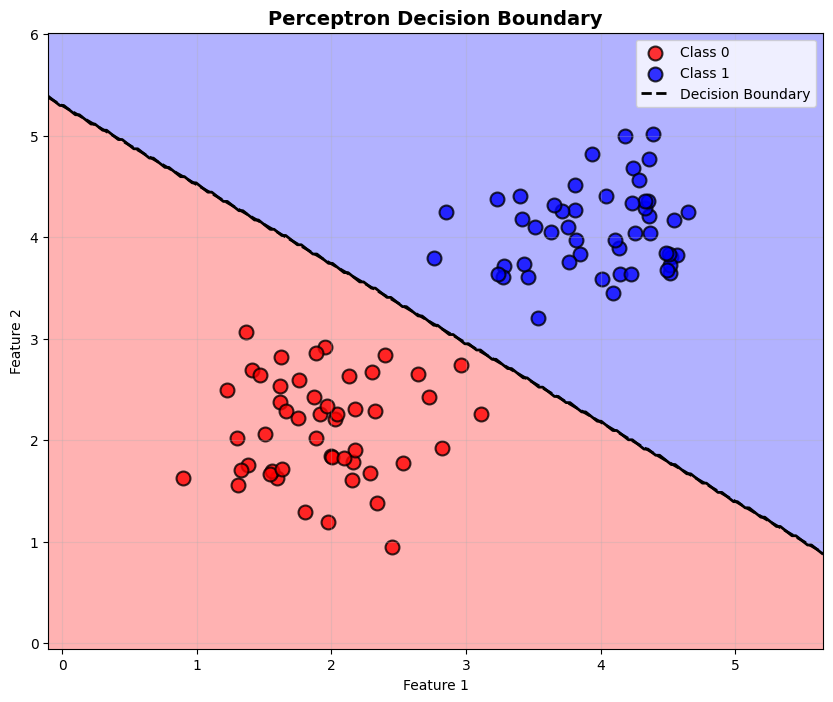

In [7]:
def plot_decision_boundary(X, y, model, title="Perceptron Decision Boundary"):
    """
    Plot decision boundary for 2D data
    """
    plt.figure(figsize=(10, 8))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh grid
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape).numpy()
    
    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, levels=1, colors=['red', 'blue'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # Plot data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', 
                s=100, alpha=0.8, edgecolors='black', linewidths=1.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', 
                s=100, alpha=0.8, edgecolors='black', linewidths=1.5)
    
    # Plot decision boundary line explicitly using weights
    # Decision boundary: w1*x1 + w2*x2 + b = 0
    # Solving for x2: x2 = -(w1*x1 + b) / w2
    w1, w2 = model.weights
    b = model.bias
    
    x_line = np.linspace(x_min, x_max, 100)
    if w2 != 0:
        y_line = -(w1 * x_line + b) / w2
        plt.plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

# Plot decision boundary
plot_decision_boundary(X, y, perceptron)

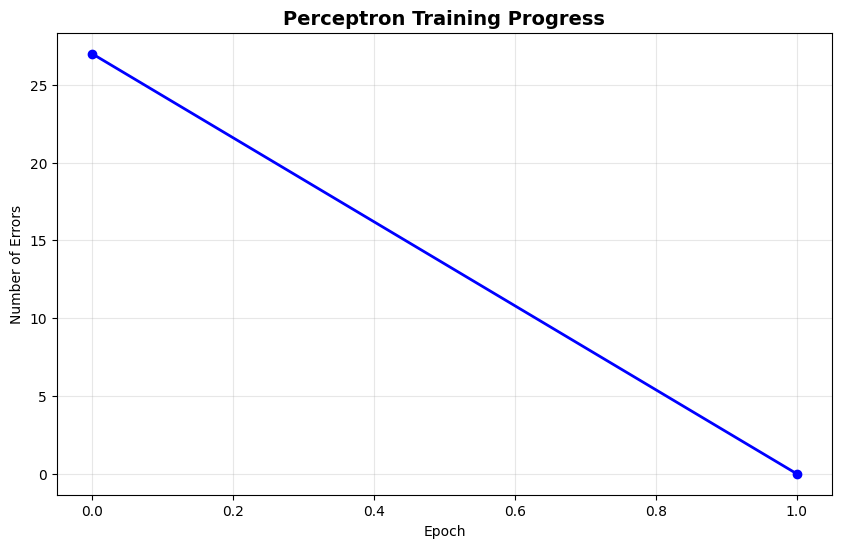

Training converged in 2 epochs


In [8]:
# Plot training errors over epochs
plt.figure(figsize=(10, 6))
epochs_completed = len(perceptron.training_errors)
plt.plot(range(epochs_completed), perceptron.training_errors, 'b-', linewidth=2, marker='o')
plt.title('Perceptron Training Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training converged in {epochs_completed} epochs")

In [9]:
print("=" * 60)
print("SIMPLE EXAMPLE: 4 Points, 2 Classes")
print("=" * 60)

# Create simple data - linearly separable
simple_X = torch.tensor([
    [1.0, 1.0],   # Class 0
    [1.5, 1.0],   # Class 0
    [3.0, 3.0],   # Class 1
    [3.5, 3.5]    # Class 1
])

simple_y = torch.tensor([0, 0, 1, 1])

print(f"\nData points:")
for i in range(len(simple_X)):
    print(f"  P{i+1}: {simple_X[i].tolist()} -> Class {simple_y[i].item()}")

print()

SIMPLE EXAMPLE: 4 Points, 2 Classes

Data points:
  P1: [1.0, 1.0] -> Class 0
  P2: [1.5, 1.0] -> Class 0
  P3: [3.0, 3.0] -> Class 1
  P4: [3.5, 3.5] -> Class 1



In [10]:
# Train Perceptron on simple data
print("\n" + "=" * 60)
print("TRAINING PERCEPTRON")
print("=" * 60 + "\n")

perceptron_simple = Perceptron(learning_rate=0.1, n_epochs=20)
perceptron_simple.fit(simple_X, simple_y)

# Make predictions
simple_predictions = perceptron_simple.predict(simple_X)

print(f"\n" + "=" * 60)
print("PREDICTIONS")
print("=" * 60)
for i in range(len(simple_X)):
    pred = simple_predictions[i].item()
    actual = simple_y[i].item()
    status = "✓" if pred == actual else "✗"
    print(f"  P{i+1}: Predicted = {pred}, Actual = {actual} {status}")


TRAINING PERCEPTRON

Training Perceptron
Learning rate: 0.1
Epochs: 20
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =   2, Accuracy = 50.00%

Converged at epoch 3! No classification errors.

Final weights: [2.9802322387695312e-08, 0.10000001639127731]
Final bias: -0.3000

PREDICTIONS
  P1: Predicted = 0, Actual = 0 ✓
  P2: Predicted = 0, Actual = 0 ✓
  P3: Predicted = 1, Actual = 1 ✓
  P4: Predicted = 1, Actual = 1 ✓


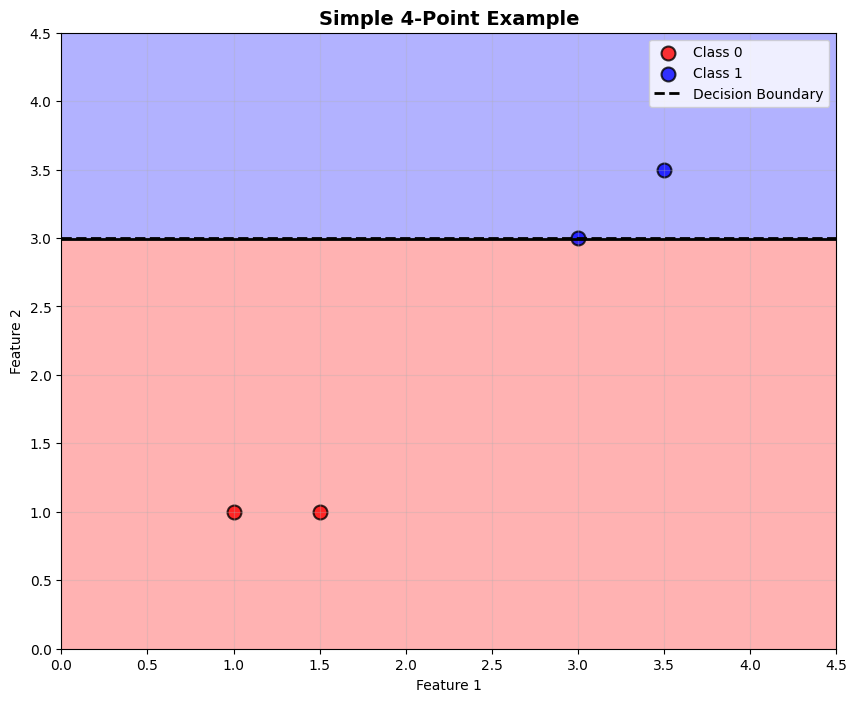

In [11]:
# Visualize simple example
plot_decision_boundary(simple_X, simple_y, perceptron_simple, 
                      title="Simple 4-Point Example")

In [12]:
# Train with verbose weight tracking
print("=" * 70)
print("STEP-BY-STEP WEIGHT UPDATES (First Epoch)")
print("=" * 70)

# Create new perceptron
perceptron_verbose = Perceptron(learning_rate=0.1, n_epochs=1)
perceptron_verbose.weights = torch.zeros(2)
perceptron_verbose.bias = torch.tensor(0.0)

print(f"Initial: w = {perceptron_verbose.weights.tolist()}, b = {perceptron_verbose.bias.item():.4f}\n")

# Manually iterate through first epoch to show updates
for i in range(len(simple_X)):
    x_i = simple_X[i]
    y_i = simple_y[i]
    
    # Compute prediction
    z = torch.dot(perceptron_verbose.weights, x_i) + perceptron_verbose.bias
    y_pred = perceptron_verbose.activation(z).long().item()
    
    print(f"Sample {i+1}: x = {x_i.tolist()}, y = {y_i.item()}")
    print(f"  z = w^T·x + b = {z.item():.4f}")
    print(f"  Predicted: {y_pred}")
    
    # Update if error
    error = y_i - y_pred
    if error != 0:
        old_w = perceptron_verbose.weights.clone()
        old_b = perceptron_verbose.bias.clone()
        
        perceptron_verbose.weights += perceptron_verbose.learning_rate * error * x_i
        perceptron_verbose.bias += perceptron_verbose.learning_rate * error
        
        print(f"  Error: {error.item()} -> UPDATE")
        print(f"  w: {old_w.tolist()} -> {perceptron_verbose.weights.tolist()}")
        print(f"  b: {old_b.item():.4f} -> {perceptron_verbose.bias.item():.4f}")
    else:
        print(f"  Error: 0 -> No update")
    
    print()

STEP-BY-STEP WEIGHT UPDATES (First Epoch)
Initial: w = [0.0, 0.0], b = 0.0000

Sample 1: x = [1.0, 1.0], y = 0
  z = w^T·x + b = 0.0000
  Predicted: 1
  Error: -1 -> UPDATE
  w: [0.0, 0.0] -> [-0.10000000149011612, -0.10000000149011612]
  b: 0.0000 -> -0.1000

Sample 2: x = [1.5, 1.0], y = 0
  z = w^T·x + b = -0.3500
  Predicted: 0
  Error: 0 -> No update

Sample 3: x = [3.0, 3.0], y = 1
  z = w^T·x + b = -0.7000
  Predicted: 0
  Error: 1 -> UPDATE
  w: [-0.10000000149011612, -0.10000000149011612] -> [0.20000001788139343, 0.20000001788139343]
  b: -0.1000 -> 0.0000

Sample 4: x = [3.5, 3.5], y = 1
  z = w^T·x + b = 1.4000
  Predicted: 1
  Error: 0 -> No update



Training Perceptron
Learning rate: 0.01
Epochs: 50
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =  27, Accuracy = 73.00%

Converged at epoch 1! No classification errors.

Final weights: [0.0132465660572052, 0.016992587596178055]
Final bias: -0.0900
Training Perceptron
Learning rate: 0.1
Epochs: 50
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =  27, Accuracy = 73.00%

Converged at epoch 1! No classification errors.

Final weights: [0.13246561586856842, 0.16992579400539398]
Final bias: -0.9000
Training Perceptron
Learning rate: 0.5
Epochs: 50
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =  27, Accuracy = 73.00%

Converged at epoch 1! No classification errors.

Final weights: [0.6623282432556152, 0.8496289849281311]
Final bias: -4.5000
Training Perceptron
Learning rate: 1.0
Epochs: 50
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =  27, Accuracy = 73.00%

Converged at epoch 1! No classification errors.

Final w

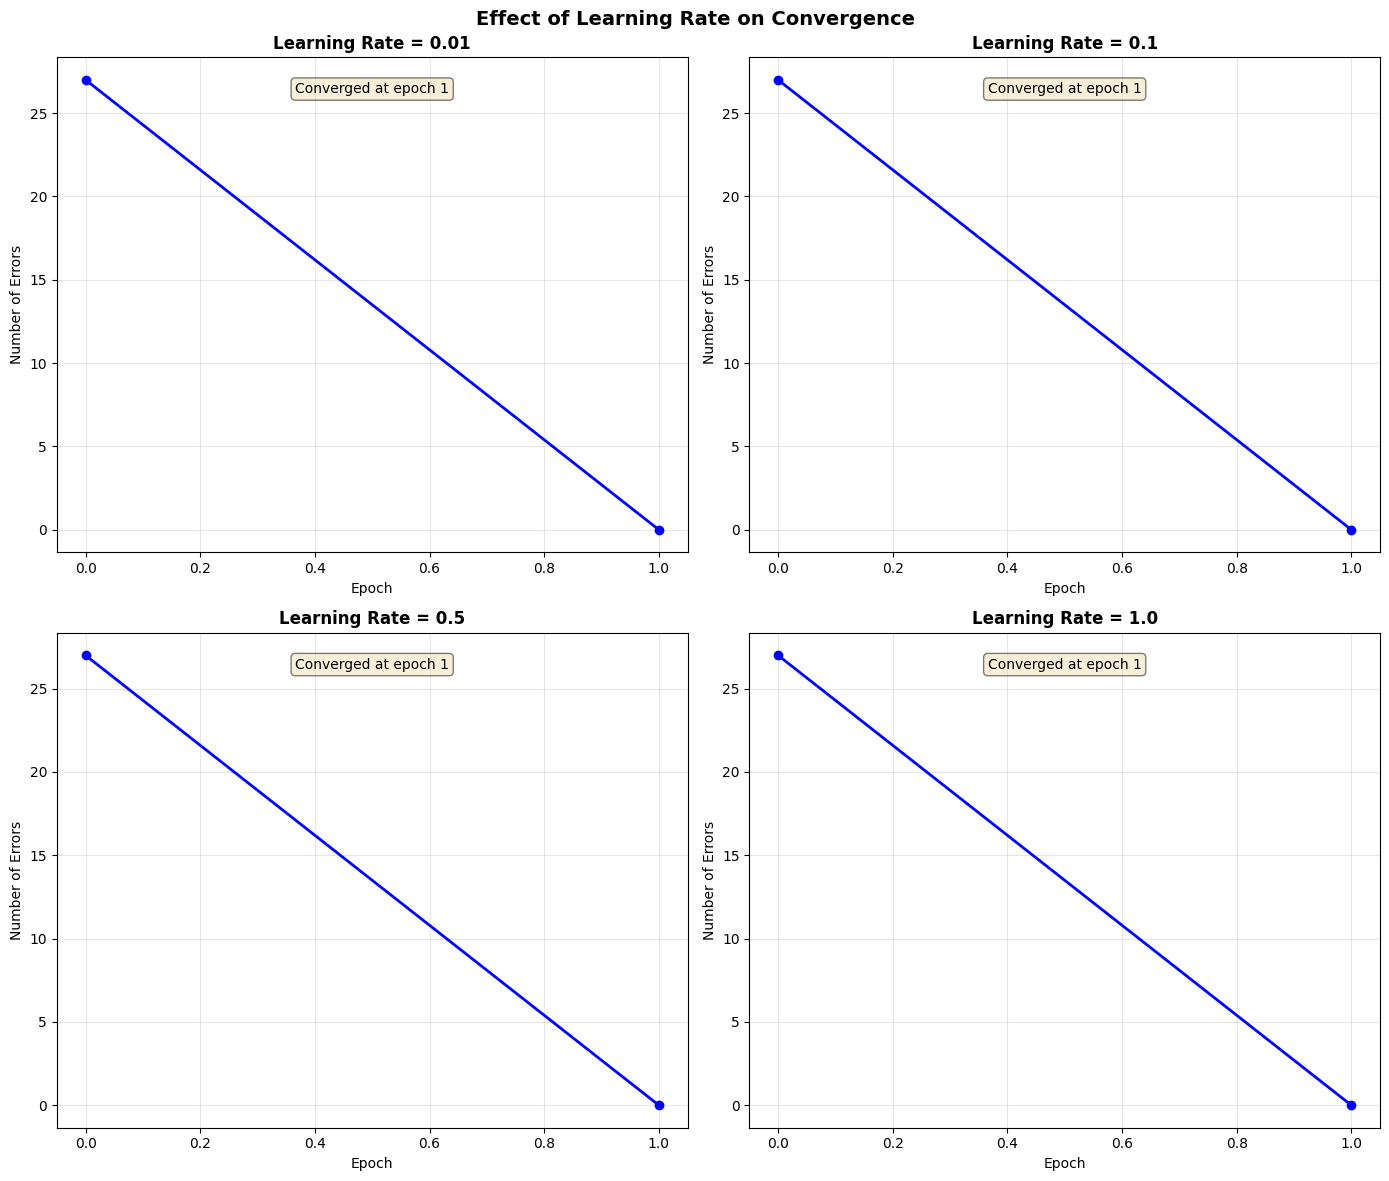


Learning Rate Effects:
- Too small (0.01): Slow convergence, more epochs needed
- Optimal (0.1-0.5): Fast convergence
- Too large (1.0): May oscillate but still converges for linearly separable data


In [13]:
# Try different learning rates
learning_rates = [0.01, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    
    # Train perceptron
    p = Perceptron(learning_rate=lr, n_epochs=50)
    p.fit(X, y)
    
    # Plot training errors
    ax.plot(range(len(p.training_errors)), p.training_errors, 'b-', linewidth=2, marker='o')
    ax.set_title(f'Learning Rate = {lr}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Number of Errors')
    ax.grid(True, alpha=0.3)
    
    # Add convergence info
    converged_epoch = len(p.training_errors) - 1
    ax.text(0.5, 0.95, f'Converged at epoch {converged_epoch}', 
           transform=ax.transAxes, ha='center', va='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Effect of Learning Rate on Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLearning Rate Effects:")
print("- Too small (0.01): Slow convergence, more epochs needed")
print("- Optimal (0.1-0.5): Fast convergence")
print("- Too large (1.0): May oscillate but still converges for linearly separable data")

In [14]:
# XOR problem - non-linearly separable
print("=" * 60)
print("XOR PROBLEM (Non-Linearly Separable)")
print("=" * 60)

# XOR data
X_xor = torch.tensor([
    [0.0, 0.0],  # Class 0
    [0.0, 1.0],  # Class 1
    [1.0, 0.0],  # Class 1
    [1.0, 1.0]   # Class 0
])

y_xor = torch.tensor([0, 1, 1, 0])

print(f"\nXOR Truth Table:")
print(f"{'X1':<6} {'X2':<6} {'Output'}")
print("-" * 20)
for i in range(len(X_xor)):
    print(f"{X_xor[i, 0].item():<6.0f} {X_xor[i, 1].item():<6.0f} {y_xor[i].item()}")

# Try to train Perceptron on XOR
print("\n" + "=" * 60)
print("Attempting to train Perceptron on XOR...")
print("=" * 60 + "\n")

perceptron_xor = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_xor.fit(X_xor, y_xor)

# Evaluate
predictions_xor = perceptron_xor.predict(X_xor)
accuracy_xor = perceptron_xor.score(X_xor, y_xor)

print(f"\nXOR Results:")
print(f"Accuracy: {accuracy_xor * 100:.2f}%")
print(f"\nPredictions vs Actual:")
for i in range(len(X_xor)):
    pred = predictions_xor[i].item()
    actual = y_xor[i].item()
    status = "✓" if pred == actual else "✗"
    print(f"  {X_xor[i].tolist()} -> Predicted: {pred}, Actual: {actual} {status}")

print("\nConclusion: Perceptron CANNOT solve XOR (non-linearly separable)!")
print("This limitation led to the development of Multi-Layer Neural Networks.")

XOR PROBLEM (Non-Linearly Separable)

XOR Truth Table:
X1     X2     Output
--------------------
0      0      0
0      1      1
1      0      1
1      1      0

Attempting to train Perceptron on XOR...

Training Perceptron
Learning rate: 0.1
Epochs: 100
Initial weights: [0.0, 0.0]
Initial bias: 0.0

Epoch   0: Errors =   3, Accuracy = 25.00%
Epoch  10: Errors =   4, Accuracy = 0.00%
Epoch  20: Errors =   4, Accuracy = 0.00%
Epoch  30: Errors =   4, Accuracy = 0.00%
Epoch  40: Errors =   4, Accuracy = 0.00%
Epoch  50: Errors =   4, Accuracy = 0.00%
Epoch  60: Errors =   4, Accuracy = 0.00%
Epoch  70: Errors =   4, Accuracy = 0.00%
Epoch  80: Errors =   4, Accuracy = 0.00%
Epoch  90: Errors =   4, Accuracy = 0.00%
Epoch  99: Errors =   4, Accuracy = 0.00%

Final weights: [-0.10000000149011612, 0.0]
Final bias: 0.0000

XOR Results:
Accuracy: 50.00%

Predictions vs Actual:
  [0.0, 0.0] -> Predicted: 1, Actual: 0 ✗
  [0.0, 1.0] -> Predicted: 1, Actual: 1 ✓
  [1.0, 0.0] -> Predicted: 0, Act

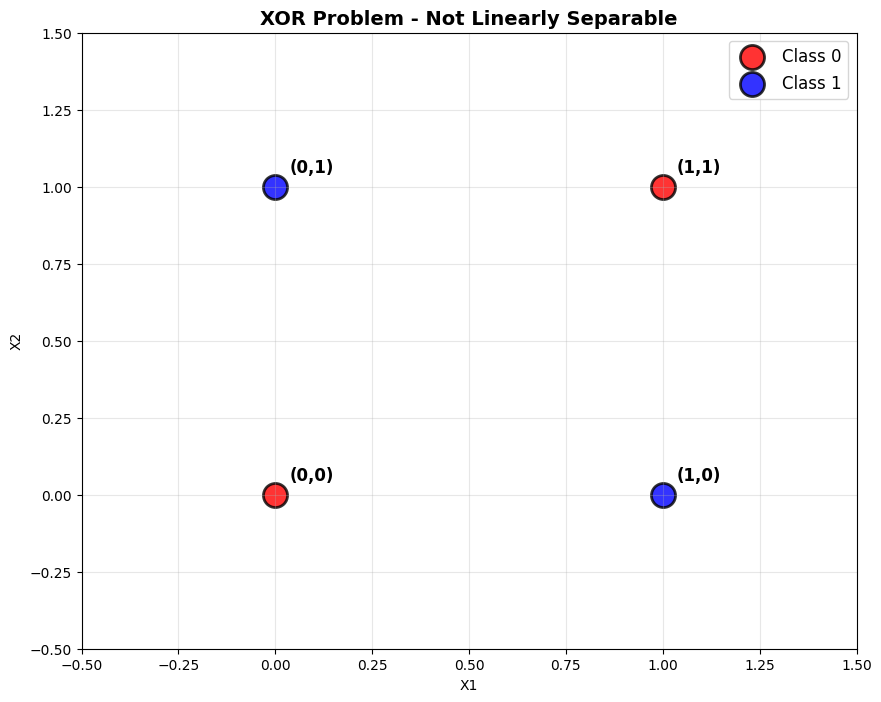

No single line can separate the red and blue points!


In [15]:
# Visualize XOR problem
plt.figure(figsize=(10, 8))

# Plot XOR data
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
           c='red', s=300, label='Class 0', alpha=0.8, edgecolors='black', linewidths=2)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
           c='blue', s=300, label='Class 1', alpha=0.8, edgecolors='black', linewidths=2)

# Try to plot decision boundary (will be wrong)
x_line = np.linspace(-0.5, 1.5, 100)
w1, w2 = perceptron_xor.weights
b = perceptron_xor.bias

if w2 != 0:
    y_line = -(w1 * x_line + b) / w2
    plt.plot(x_line, y_line, 'k--', linewidth=2, label='Perceptron Decision Boundary')

# Annotate points
for i, point in enumerate(X_xor):
    plt.annotate(f'({point[0]:.0f},{point[1]:.0f})', 
                xy=point, xytext=(10, 10), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('XOR Problem - Not Linearly Separable', fontsize=14, fontweight='bold')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

print("No single line can separate the red and blue points!")